In [2]:
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.2 kB/s eta 0:00:0000:0100:02


In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# =============================
# LOAD DATA
# =============================
df = pd.read_csv("final_ml_dataset.csv")

target_col = "Label"   # change if needed
y = df[target_col]
X = df.drop(columns=[target_col])

# keep numeric only
X = X.select_dtypes(include=[np.number])

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# scaled version for ANN later
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []

# =============================
# RANDOM FOREST
# =============================
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)
rf.fit(X_train, y_train)

rf_prob = rf.predict_proba(X_test)[:,1]
rf_pred = rf.predict(X_test)

results.append([
    "Random Forest",
    accuracy_score(y_test, rf_pred),
    roc_auc_score(y_test, rf_prob)
])

# =============================
# XGBOOST
# =============================
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_prob = xgb.predict_proba(X_test)[:,1]
xgb_pred = xgb.predict(X_test)

results.append([
    "XGBoost",
    accuracy_score(y_test, xgb_pred),
    roc_auc_score(y_test, xgb_prob)
])

# =============================
# LIGHTGBM
# =============================
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

lgbm.fit(X_train, y_train)

lgbm_prob = lgbm.predict_proba(X_test)[:,1]
lgbm_pred = lgbm.predict(X_test)

results.append([
    "LightGBM",
    accuracy_score(y_test, lgbm_pred),
    roc_auc_score(y_test, lgbm_prob)
])

# =============================
# RESULTS TABLE
# =============================
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "AUC"]
)

print(results_df.sort_values("AUC", ascending=False))

[LightGBM] [Info] Number of positive: 294, number of negative: 83
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000739 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9689
[LightGBM] [Info] Number of data points in the train set: 377, number of used features: 100
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.779841 -> initscore=1.264739
[LightGBM] [Info] Start training from score 1.264739
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [6]:
import pandas as pd

importance_df = pd.DataFrame({
    "Gene": X.columns,
    "Importance": lgbm.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

top200 = importance_df.head(200)

print(top200)

top200.to_csv("top_200_genes_lightgbm.csv", index=False)
print("Saved: top_200_genes_lightgbm.csv")

       Gene  Importance
93     EBF2         159
8    FAM83H         146
41  TNFSF11         133
3        C7         129
0      MMP3         122
..      ...         ...
33   CALML3           0
82    CWH43           0
37    KRT6A           0
62     KRT5           0
38  LGALS7B           0

[100 rows x 2 columns]
Saved: top_200_genes_lightgbm.csv


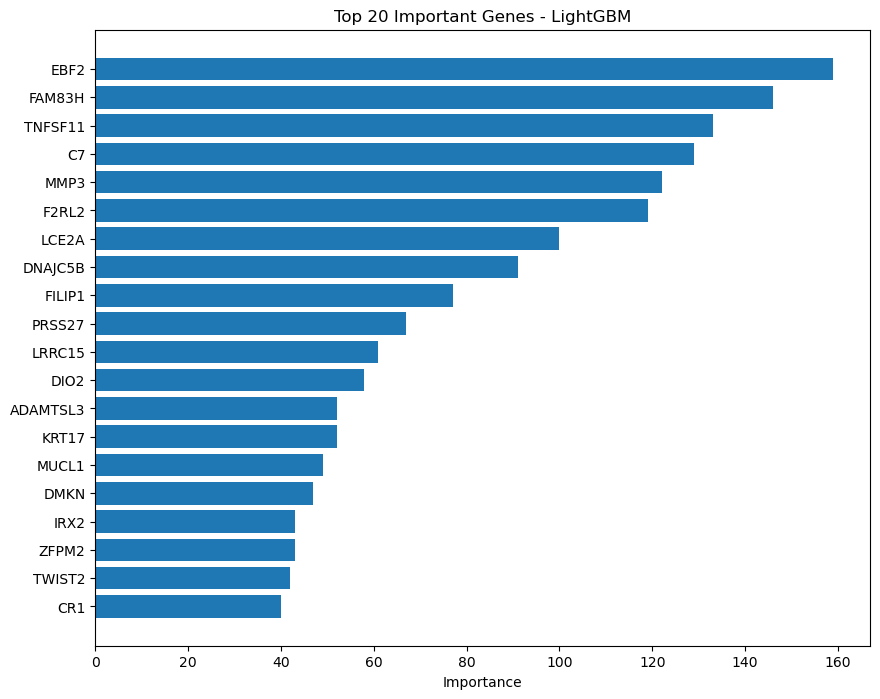

In [7]:
import matplotlib.pyplot as plt

top20 = top200.head(20)

plt.figure(figsize=(10,8))
plt.barh(top20["Gene"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Genes - LightGBM")
plt.xlabel("Importance")
plt.show()

In [8]:
!pip install shap

  Using cached numpy-2.4.4-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached numpy-2.2.6-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
Using cached numpy-2.2.6-cp312-cp312-macosx_14_0_arm64.whl (5.1 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.8 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.2.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.2.6 which is incompatible.


/opt/anaconda3/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


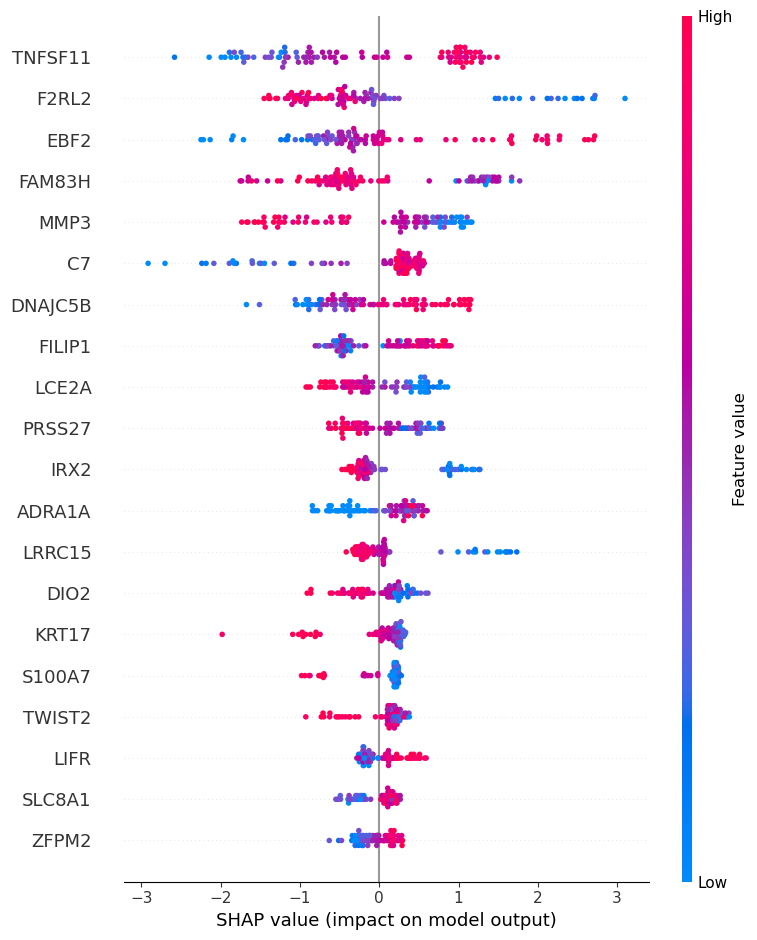

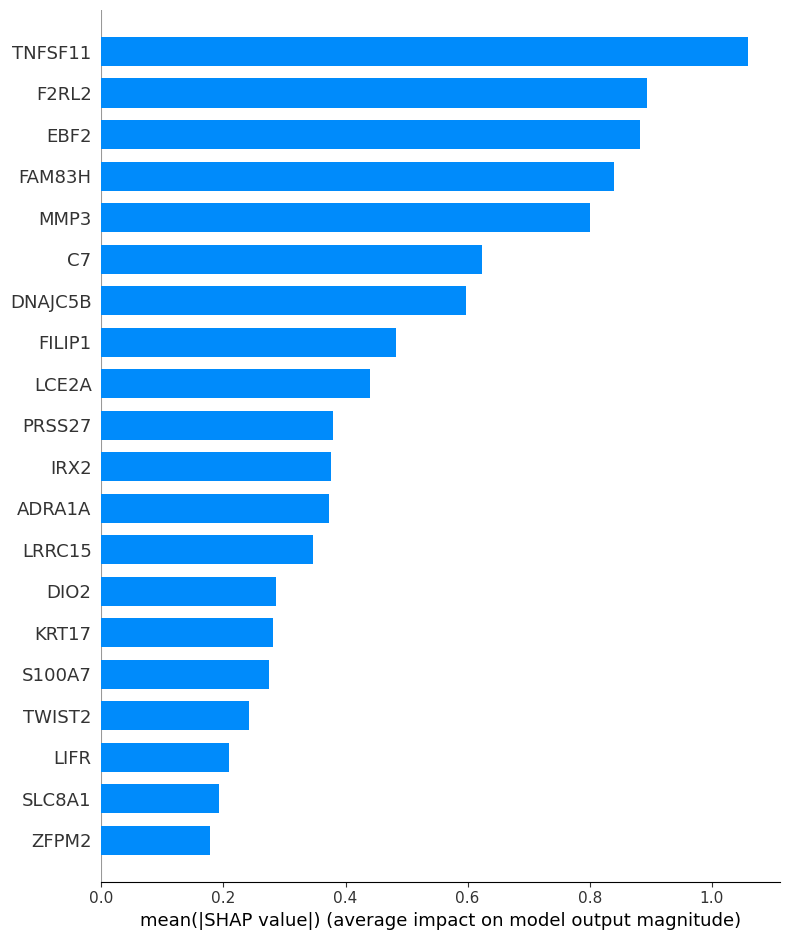

In [9]:
import shap
import matplotlib.pyplot as plt


explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_plot_values = shap_values[1]
else:
    shap_plot_values = shap_values


shap.summary_plot(
    shap_plot_values,
    X_test,
    feature_names=X.columns
)


shap.summary_plot(
    shap_plot_values,
    X_test,
    feature_names=X.columns,
    plot_type="bar"
)